   horas_estudio  asistencia  aprueba
0       3.745401   82.101582        1
1       9.507143   54.206998        1
2       7.319939   58.081436        1
3       5.986585   94.927709        1
4       1.560186   80.321453        0


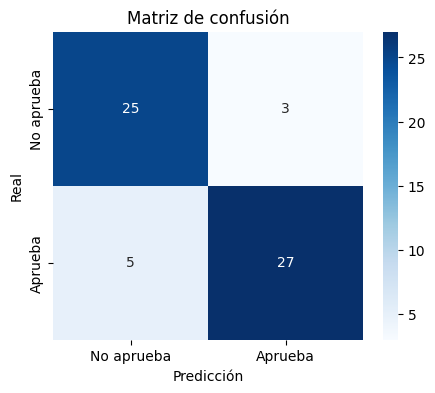

Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        28
           1       0.90      0.84      0.87        32

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

np.random.seed(42)

# --- Dataset sintético ---
n = 200
horas_estudio = np.random.uniform(0, 10, n)
asistencia = np.random.uniform(50, 100, n)

score = (horas_estudio * 6) + (asistencia * 0.5) + np.random.normal(0, 10, n)
aprueba = (score > np.percentile(score, 50)).astype(int)

df = pd.DataFrame({
    "horas_estudio": horas_estudio,
    "asistencia": asistencia,
    "aprueba": aprueba
})

print(df.head())

# --- Entrenamiento ---
X = df[["horas_estudio", "asistencia"]]
y = df["aprueba"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No aprueba", "Aprueba"],
            yticklabels=["No aprueba", "Aprueba"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

# --- Métricas ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))